# Growth vs Emissions: Which Countries Have Decoupled?

*Which countries have grown their economy while cutting CO₂ emissions and what distinguishes them from those that haven't?*

"Decoupling" is the central idea in climate-and-growth debates. We usually assume a bigger economy means more emissions, but some countries have broken that link. This notebook tries to find them, and classify every country by how its emissions and economy moved together from 1995–2022, and then groups countries into natural types using clustering.

**Dataset:** Our World in Data — *Complete CO₂ and Greenhouse Gas Emissions* (one CSV, ~50k rows, 79 columns, country-by-year).


**Approach**
1. Load the raw CSV into SQLite as text (*stage raw, transform later*).
2. Clean it **with SQL**: drop aggregate rows, cast types, turn blanks into NULLs.
3. Build one row per country describing its decoupling behaviour.
4. Cluster countries to surface natural groups, and visualise the pattern.

Cleaning is done in SQL on purpose, as with this project I want to demonstrate my SQL skills.

## 0. Setup

We use **SQLite** (built into Python, no install) for the cleaning, and pandas / scikit-learn / matplotlib for the analysis. The cell below downloads the dataset if it isn't already next to the notebook.

In [1]:
import os, urllib.request
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

CSV = "owid-co2-data.csv"
URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
if not os.path.exists(CSV):
    print("Downloading dataset ...")
    urllib.request.urlretrieve(URL, CSV)
print("Dataset ready:", os.path.getsize(CSV) // 1_000_000, "MB")

Dataset ready: 14 MB


## 1. Load the raw data into SQLite (*stage raw, transform later*)

Real-world CSVs are full of values that break a typed import like blank cells, stray text in number columns. So my first move is to load **everything as text** into a `staging` table and clean it afterwards. Nothing is interpreted yet; we just get the data into the database untouched.

Reading with `dtype=str` and `na_filter=False` keeps blanks as empty strings `''` (exactly how a raw CSV import behaves), which we'll deal with deliberately in the next step.

In [2]:
con = sqlite3.connect(":memory:")   # in-memory DB; use a filename to persist

raw = pd.read_csv(CSV, dtype=str, na_filter=False)   # everything as text
raw.to_sql("staging", con, index=False, if_exists="replace")
print("staging shape:", raw.shape)


pd.read_sql_query("SELECT country, year, iso_code, co2, gdp FROM staging LIMIT 5", con)

staging shape: (50411, 79)


,country,year,iso_code,co2,gdp
0,Afghanistan,1750,AFG,,
1,Afghanistan,1751,AFG,,
2,Afghanistan,1752,AFG,,
3,Afghanistan,1753,AFG,,
4,Afghanistan,1754,AFG,,


## 2. Clean the data with SQL

Two cleaning decisions matter most here.

**(a) Aggregates hide among the countries.** The `country` column secretly mixes real nations (`France`) with totals like `World`, `Asia`, `High-income countries`, and `International aviation`. If you rank or average without removing these, every result is wrong. Real countries carry a 3-letter ISO code; aggregates don't so we filter on it:
`LENGTH(iso_code) = 3 AND iso_code GLOB '[A-Za-z][A-Za-z][A-Za-z]'`.

**(b) Empty strings aren't zero.** After a text import, missing values are `''`. `NULLIF(col, '')` converts them to real NULLs *before* `CAST`, so missing data stays missing instead of silently becoming `0` and dragging down averages.

In [3]:
clean_sql = """
DROP TABLE IF EXISTS clean_emissions;
CREATE TABLE clean_emissions AS
SELECT
    country,
    iso_code,
    CAST(year AS INTEGER)                                 AS year,
    CAST(NULLIF(population, '') AS REAL)                  AS population,
    CAST(NULLIF(gdp, '') AS REAL)                         AS gdp,
    CAST(NULLIF(co2, '') AS REAL)                         AS co2,             -- million tonnes
    CAST(NULLIF(co2_per_capita, '') AS REAL)             AS co2_per_capita,
    CAST(NULLIF(consumption_co2, '') AS REAL)            AS consumption_co2,  -- footprint incl. imports
    CAST(NULLIF(coal_co2, '') AS REAL)                   AS coal_co2,
    CAST(NULLIF(oil_co2, '') AS REAL)                    AS oil_co2,
    CAST(NULLIF(gas_co2, '') AS REAL)                    AS gas_co2,
    CAST(NULLIF(share_global_co2, '') AS REAL)           AS share_global_co2
FROM staging
WHERE LENGTH(iso_code) = 3
  AND iso_code GLOB '[A-Za-z][A-Za-z][A-Za-z]';   -- keep only real countries
"""
con.executescript(clean_sql)

before = pd.read_sql_query("SELECT COUNT(*) n FROM staging", con).n[0]
after  = pd.read_sql_query("SELECT COUNT(*) n FROM clean_emissions", con).n[0]
countries = pd.read_sql_query("SELECT COUNT(DISTINCT country) n FROM clean_emissions", con).n[0]
print(f"staging rows:         {before:,}")
print(f"clean_emissions rows: {after:,}   (dropped {before-after:,} aggregate rows)")
print(f"distinct countries:   {countries}")

pd.read_sql_query(
    "SELECT country, year, co2, gdp, co2_per_capita "
    "FROM clean_emissions WHERE country='Germany' AND year>=2018 ORDER BY year", con)

staging rows:         50,411
clean_emissions rows: 42,480   (dropped 7,931 aggregate rows)
distinct countries:   218


,country,year,co2,gdp,co2_per_capita
0,Germany,2018,758.771,3.845759e+12,9.101
1,Germany,2019,708.649,3.886393e+12,8.481
2,Germany,2020,647.177,3.742721e+12,7.739
3,Germany,2021,677.998,3.841042e+12,8.101
4,Germany,2022,667.843,3.909613e+12,7.942
5,Germany,2023,593.766,NaN,7.023
6,Germany,2024,572.319,NaN,6.769


## 3. Build the decoupling features (still in SQL)

Now we collapse the panel to **one row per country** describing how it changed over 1995–2022, and label each with a decoupling class:

| Class | Meaning |
|---|---|
| **Absolute decoupling** | GDP up, CO₂ **down** — the goal |
| **Relative decoupling** | GDP up, CO₂ up but slower |
| **Coupled growth** | CO₂ up as fast as (or faster than) GDP |
| **GDP decline** | Economy shrank — can't credit policy for the CO₂ fall |

**Why this window is chosen?** GDP coverage in the dataset ends in 2022, so that's the last year where CO₂ *and* GDP exist together. We require ≥25 years of data so the trend is meaningful.

**A note on `WHERE` vs window functions:** we use `ROW_NUMBER() OVER (PARTITION BY country ORDER BY year)` to grab each country's first and last year inside the window. Window functions let us compare rows *within* a group without collapsing them, which a plain `GROUP BY` can't do.

In [4]:
features_sql = """
DROP TABLE IF EXISTS country_features;
CREATE TABLE country_features AS
WITH windowed AS (
    SELECT * FROM clean_emissions
    WHERE year BETWEEN 1995 AND 2022 AND co2 IS NOT NULL AND gdp IS NOT NULL
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY country ORDER BY year ASC)  AS rn_first,
        ROW_NUMBER() OVER (PARTITION BY country ORDER BY year DESC) AS rn_last,
        COUNT(*)     OVER (PARTITION BY country)                    AS n_years
    FROM windowed
),
endpoints AS (
    SELECT country,
        MAX(n_years) AS n_years,
        MAX(CASE WHEN rn_first=1 THEN co2 END) AS co2_start,
        MAX(CASE WHEN rn_last =1 THEN co2 END) AS co2_end,
        MAX(CASE WHEN rn_first=1 THEN gdp END) AS gdp_start,
        MAX(CASE WHEN rn_last =1 THEN gdp END) AS gdp_end,
        MAX(CASE WHEN rn_last =1 THEN co2_per_capita END) AS co2_per_capita_latest,
        MAX(CASE WHEN rn_last =1 THEN coal_co2 END)       AS coal_co2_latest
    FROM ranked GROUP BY country
)
SELECT country, n_years,
    ROUND(100.0*(co2_end-co2_start)/co2_start, 1) AS co2_change_pct,
    ROUND(100.0*(gdp_end-gdp_start)/gdp_start, 1) AS gdp_change_pct,
    ROUND(co2_per_capita_latest, 2)               AS co2_per_capita_latest,
    CASE WHEN co2_end>0 THEN ROUND(100.0*coal_co2_latest/co2_end,1) END AS coal_share_pct_latest,
    CASE
        WHEN gdp_end <= gdp_start THEN 'GDP decline'
        WHEN co2_end <  co2_start THEN 'Absolute decoupling'
        WHEN (100.0*(co2_end-co2_start)/co2_start) < (100.0*(gdp_end-gdp_start)/gdp_start)
                                  THEN 'Relative decoupling'
        ELSE 'Coupled growth'
    END AS decoupling_class
FROM endpoints
WHERE n_years >= 25 AND co2_start > 0 AND gdp_start > 0
ORDER BY co2_change_pct ASC;
"""
con.executescript(features_sql)

summary = pd.read_sql_query(
    "SELECT decoupling_class, COUNT(*) AS n_countries "
    "FROM country_features GROUP BY decoupling_class ORDER BY n_countries DESC", con)
summary

,decoupling_class,n_countries
0,Relative decoupling,86
1,Coupled growth,38
2,Absolute decoupling,38
3,GDP decline,2


So most countries managed *relative* decoupling, and a meaningful group — 38 countries — achieved *absolute* decoupling. Let's see the strongest decarbonisers:

In [5]:
pd.read_sql_query(
    "SELECT country, co2_change_pct, gdp_change_pct, decoupling_class "
    "FROM country_features ORDER BY co2_change_pct ASC LIMIT 10", con)

,country,co2_change_pct,gdp_change_pct,decoupling_class
0,Ukraine,-63.3,20.1,Absolute decoupling
1,Moldova,-54.6,53.0,Absolute decoupling
2,Denmark,-52.8,71.6,Absolute decoupling
3,United Kingdom,-45.0,61.1,Absolute decoupling
4,Romania,-41.8,269.9,Absolute decoupling
5,Sweden,-38.9,96.3,Absolute decoupling
6,Finland,-37.5,71.9,Absolute decoupling
7,Greece,-33.8,47.7,Absolute decoupling
8,Estonia,-33.7,114.7,Absolute decoupling
9,Syria,-32.3,-63.0,GDP decline


**An honest caveat.** Denmark, the UK, Sweden and Finland are real clean-energy success stories: they grew while genuinely cutting emissions. But Ukraine, Moldova and Romania near the top fell largely because of **post-Soviet industrial collapse**, not climate policy. Same number, very different cause. Noticing this rather than claiming every "decoupler" is a policy win is careless. 

## 4. Find natural groups with clustering

We now let an unsupervised model group countries by four features: CO₂ change, GDP change, latest CO₂ per capita, and latest coal share. Two preprocessing steps matter:

- **Winsorizing:** a few countries (e.g. Laos) have enormous % changes from a tiny base. Left alone, a single outlier captures an entire cluster. We cap the percent-change features at the 5th/95th percentile *for clustering only*.
- **Standardizing:** the features live on very different scales (percent vs tonnes-per-capita), and k-means uses distances so we scale them to comparable ranges first.

This kind of preprocesses is generally used in most classifications so that our model works correctly. 

In [7]:
df = pd.read_sql_query("SELECT * FROM country_features", con)
print(f"{len(df)} countries")

FEATURES = ["co2_change_pct", "gdp_change_pct", "co2_per_capita_latest", "coal_share_pct_latest"]
X = df[FEATURES].copy()
X = X.fillna(X.median(numeric_only=True))                 # impute the few missing values

for c in ["co2_change_pct", "gdp_change_pct"]:            # winsorize extremes
    lo, hi = X[c].quantile([0.05, 0.95]); X[c] = X[c].clip(lo, hi)

Xs = StandardScaler().fit_transform(X)                    # standardize
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(Xs)

profile = (df.groupby("cluster")[FEATURES].mean().round(1)
             .assign(n_countries=df.groupby("cluster").size()))
profile

164 countries


,co2_change_pct,gdp_change_pct,co2_per_capita_latest,coal_share_pct_latest,n_countries
cluster,,,,,
0,509.8,406.3,1.2,18.6,40
1,53.3,138.6,3.7,10.4,86
2,89.4,206.6,6.2,55.4,30
3,185.5,908.5,23.1,0.4,8


In [8]:
for c in sorted(df["cluster"].unique()):
    members = df.loc[df["cluster"]==c, "country"].tolist()
    print(f"Cluster {c} ({len(members)}): " + ", ".join(members[:9]) +
          (" ..." if len(members) > 9 else ""))

Cluster 0 (40): Azerbaijan, Nigeria, Angola, Dominican Republic, Liberia, Egypt, Iraq, Kenya, Cape Verde ...
Cluster 1 (86): Moldova, Denmark, United Kingdom, Romania, Sweden, Finland, Greece, Syria, Belgium ...
Cluster 2 (30): Ukraine, Estonia, Germany, Czechia, North Korea, Bulgaria, Zimbabwe, Japan, Poland ...
Cluster 3 (8): Kuwait, Saudi Arabia, Trinidad and Tobago, Bahrain, United Arab Emirates, Turkmenistan, Qatar, Oman


Reading the profile and members together, four recognisable types emerge:

- **Mature, low-coal economies** — modest emission growth; this group contains the absolute decouplers (Denmark, UK, Sweden).
- **Fast-growing developing emitters** — large % CO₂ growth from a low base.
- **Coal-heavy industrial economies** — high coal share (Poland, Czechia, and post-industrial transitions like Germany/Ukraine).
- **High-per-capita petrostates** — Qatar, UAE, Saudi Arabia, Kuwait.

(Cluster numbers are assigned randomly by k-means, so match each number to its profile row above.)

## 5. Visualise the decoupling pattern

The clearest single chart is GDP change vs CO₂ change. Anything **below the black line** grew its economy while cutting emissions that means absolute decoupling. Two extreme outliers (Laos, Qatar) sit off-scale, so we zoom to where most countries live.

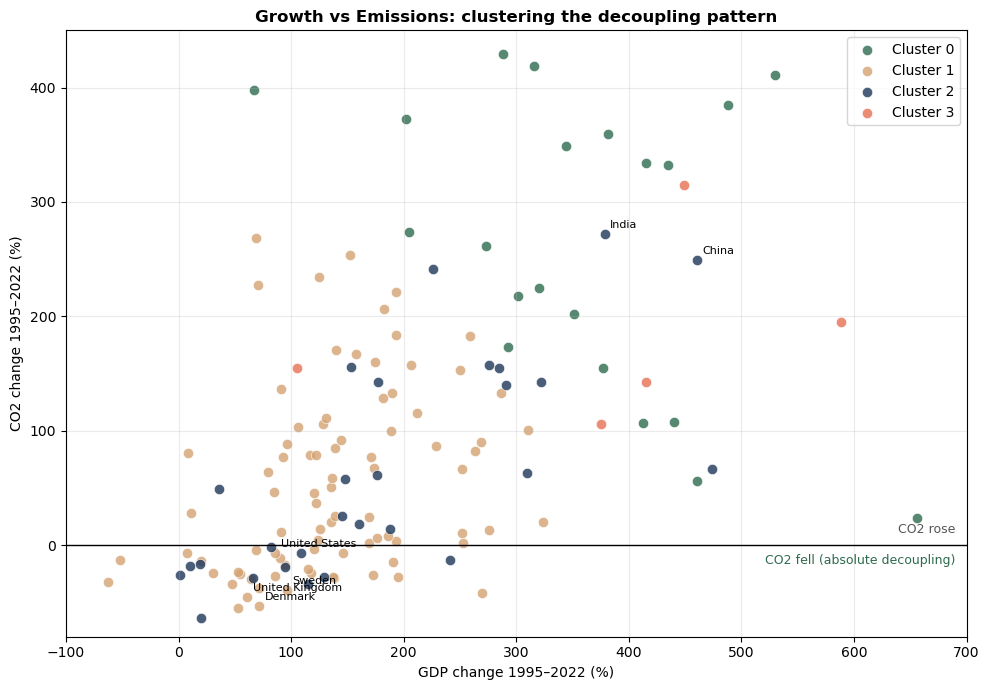

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = ["#2d6a4f", "#d4a373", "#1d3557", "#e76f51"]
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"]==c]
    ax.scatter(sub["gdp_change_pct"], sub["co2_change_pct"], s=55, alpha=0.8,
               color=palette[c % len(palette)], edgecolor="white", linewidth=0.5,
               label=f"Cluster {c}")
ax.axhline(0, color="black", lw=1)
ax.set_xlim(-100, 700); ax.set_ylim(-80, 450)
ax.text(690, 8,  "CO2 rose", ha="right", va="bottom", fontsize=9, color="#555")
ax.text(690, -8, "CO2 fell (absolute decoupling)", ha="right", va="top", fontsize=9, color="#2d6a4f")
for name in ["Denmark", "United Kingdom", "Sweden", "China", "India", "United States"]:
    row = df[df["country"]==name]
    if not row.empty:
        ax.annotate(name, (row["gdp_change_pct"].values[0], row["co2_change_pct"].values[0]),
                    fontsize=8, xytext=(4,4), textcoords="offset points")
ax.set_xlabel("GDP change 1995–2022 (%)"); ax.set_ylabel("CO2 change 1995–2022 (%)")
ax.set_title("Growth vs Emissions: clustering the decoupling pattern", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

## 6. Bonus: production vs consumption emissions (the "offshoring" story)

Everything above uses *territorial* emissions. What's emitted inside a country's borders. But a country can look greener simply by importing the carbon-intensive goods it used to make. **Consumption-based** emissions reassign those imports back to the consumer. Comparing the two reveals who is a net *importer* of emissions.

In [10]:
pp = pd.read_sql_query("""
    WITH latest AS (
        SELECT country, MAX(year) AS y
        FROM clean_emissions
        WHERE consumption_co2 IS NOT NULL AND co2 IS NOT NULL
        GROUP BY country
    )
    SELECT e.country,
           ROUND(e.co2,1)             AS territorial_co2,
           ROUND(e.consumption_co2,1) AS consumption_co2,
           ROUND(100.0*(e.consumption_co2-e.co2)/e.co2, 1) AS pct_higher_footprint
    FROM clean_emissions e
    JOIN latest l ON e.country=l.country AND e.year=l.y
    WHERE e.country IN ('United States','United Kingdom','Germany','France',
                        'China','India','Sweden','Norway','Japan')
    ORDER BY pct_higher_footprint DESC
""", con)
pp

,country,territorial_co2,consumption_co2,pct_higher_footprint
0,Sweden,36.7,61.7,68.1
1,United Kingdom,307.8,487.1,58.2
2,France,270.3,407.4,50.7
3,Germany,593.8,768.5,29.4
4,Japan,986.9,1142.3,15.7
5,United States,4918.4,5431.7,10.4
6,Norway,38.9,39.0,0.3
7,China,12172.0,10857.0,-10.8
8,India,3062.8,2543.2,-17.0


A positive `pct_higher_footprint` means the country's *real* carbon footprint is larger than its on-paper territorial emissions — it imports more embodied carbon than it exports. This is a more honest lens on "who has actually decarbonised" versus "who has offshored," and it's a natural next step to fold into the main analysis.

---

## Limitations & next steps

- **Endpoint sensitivity.** Comparing only the first and last year ignores the path between. A per-country regression *slope* would be more robust.
- **Outliers.** A few tiny-base countries have huge % changes; we winsorized for clustering and zoomed the chart. Both choices are explicit, not hidden.
- **Choosing k.** k = 4 was picked for interpretability but an elbow or silhouette analysis would justify it more rigorously.
- **Causation.** Decoupling ≠ good policy (see the post-Soviet caveat). Pairing this with energy-mix data would help separate genuine transitions from industrial decline.

*Built with SQLite, pandas, and scikit-learn.*